In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# ============================================================
# FUNGSI KEANGGOTAAN
# ============================================================

def trapmf(x, a, b, c, d):
    """Trapesium: naik dari a ke b, datar b–c, turun c ke d"""
    if isinstance(x, (int, float)):
        if x <= a or x >= d:
            return 0.0
        elif b <= x <= c:
            return 1.0
        elif a < x < b:
            return (x - a) / (b - a)
        elif c < x < d:
            return (d - x) / (d - c)
    else:
        y = np.zeros_like(x, dtype=float)
        for i, xi in enumerate(x):
            if xi <= a or xi >= d:
                y[i] = 0.0
            elif b <= xi <= c:
                y[i] = 1.0
            elif a < xi < b:
                y[i] = (xi - a) / (b - a)
            elif c < xi < d:
                y[i] = (d - xi) / (d - c)
        return y

def trimf(x, a, b, c):
    """Segitiga: naik dari a ke b, turun b ke c"""
    if isinstance(x, (int, float)):
        if x <= a or x >= c:
            return 0.0
        elif x == b:
            return 1.0
        elif a < x < b:
            return (x - a) / (b - a)
        elif b < x < c:
            return (c - x) / (c - b)
    else:
        y = np.zeros_like(x, dtype=float)
        for i, xi in enumerate(x):
            if xi <= a or xi >= c:
                y[i] = 0.0
            elif xi == b:
                y[i] = 1.0
            elif a < xi < b:
                y[i] = (xi - a) / (b - a)
            elif b < xi < c:
                y[i] = (c - xi) / (c - b)
        return y

In [9]:
# ============================================================
# FUZZIFIKASI INPUT
# ============================================================
# Puncak mengacu pada jurnal WHO & Kemenkes RI
# Kaki kiri = puncak tetangga kiri
# Kaki kanan = puncak tetangga kanan

def fuzzifikasi_air(A):
    """
    Konsumsi Air (L/hari), domain: 0 – 4
    Sangat Sedikit : trapmf [0,    0,    0.5,  0.9 ]
    Sedikit        : trimf  [0.5,  0.9,  1.7  ]
    Cukup          : trimf  [0.9,  1.7,  2.5  ]
    Banyak         : trimf  [1.7,  2.5,  3.2  ]
    Sangat Banyak  : trapmf [2.5,  3.2,  4.0,  4.0 ]
    """
    return {
        'Sangat Sedikit': trapmf(A, 0.0, 0.0, 0.5, 0.9),
        'Sedikit'       : trimf (A, 0.5, 0.9, 1.7),
        'Cukup'         : trimf (A, 0.9, 1.7, 2.5),
        'Banyak'        : trimf (A, 1.7, 2.5, 3.2),
        'Sangat Banyak' : trapmf(A, 2.5, 3.2, 4.0, 4.0),
    }

def fuzzifikasi_aktivitas(X):
    """
    Aktivitas Fisik (jam/hari), domain: 0 – 5
    Sangat Ringan  : trapmf [0,    0,    0.5,  1.3 ]
    Ringan         : trimf  [0.5,  1.3,  2.5  ]
    Sedang         : trimf  [1.3,  2.5,  3.7  ]
    Berat          : trimf  [2.5,  3.7,  4.5  ]
    Sangat Berat   : trapmf [3.7,  4.5,  5.0,  5.0 ]
    """
    return {
        'Sangat Ringan' : trapmf(X, 0.0, 0.0, 0.5, 1.3),
        'Ringan'        : trimf (X, 0.5, 1.3, 2.5),
        'Sedang'        : trimf (X, 1.3, 2.5, 3.7),
        'Berat'         : trimf (X, 2.5, 3.7, 4.5),
        'Sangat Berat'  : trapmf(X, 3.7, 4.5, 5.0, 5.0),
    }

In [10]:
# ============================================================
# RULE BASE (25 aturan - 5x5)
# ============================================================
# Format: (AsupanAir_set, Aktivitas_set, RisikoDehidrasi_output)

RULES = [
    # Sangat Ringan
    ('Sangat Sedikit', 'Sangat Ringan', 'Rendah'),
    ('Sedikit',        'Sangat Ringan', 'Rendah'),
    ('Cukup',          'Sangat Ringan', 'Sangat Rendah'),
    ('Banyak',         'Sangat Ringan', 'Sangat Rendah'),
    ('Sangat Banyak',  'Sangat Ringan', 'Sangat Rendah'),
    # Ringan
    ('Sangat Sedikit', 'Ringan', 'Sedang'),
    ('Sedikit',        'Ringan', 'Rendah'),
    ('Cukup',          'Ringan', 'Rendah'),
    ('Banyak',         'Ringan', 'Sangat Rendah'),
    ('Sangat Banyak',  'Ringan', 'Sangat Rendah'),
    # Sedang
    ('Sangat Sedikit', 'Sedang', 'Tinggi'),
    ('Sedikit',        'Sedang', 'Sedang'),
    ('Cukup',          'Sedang', 'Rendah'),
    ('Banyak',         'Sedang', 'Rendah'),
    ('Sangat Banyak',  'Sedang', 'Sangat Rendah'),
    # Berat
    ('Sangat Sedikit', 'Berat', 'Sangat Tinggi'),
    ('Sedikit',        'Berat', 'Tinggi'),
    ('Cukup',          'Berat', 'Sedang'),
    ('Banyak',         'Berat', 'Rendah'),
    ('Sangat Banyak',  'Berat', 'Rendah'),
    # Sangat Berat
    ('Sangat Sedikit', 'Sangat Berat', 'Sangat Tinggi'),
    ('Sedikit',        'Sangat Berat', 'Sangat Tinggi'),
    ('Cukup',          'Sangat Berat', 'Tinggi'),
    ('Banyak',         'Sangat Berat', 'Sedang'),
    ('Sangat Banyak',  'Sangat Berat', 'Rendah'),
]

In [11]:
# ============================================================
# KONSTANTA OUTPUT (untuk Max & Sugeno)
# Puncak risiko dehidrasi mengacu pada domain 0–100
# ============================================================

CONST_OUTPUT = {
    'Sangat Rendah' : 15,
    'Rendah'        : 27,
    'Sedang'        : 50,
    'Tinggi'        : 73,
    'Sangat Tinggi' : 85,
}

In [12]:
# ============================================================
# MEMBERSHIP FUNCTION OUTPUT (untuk Mamdani)
# ============================================================

def mf_risiko(r, label):
    """
    Risiko Dehidrasi (0–100):
    Sangat Rendah : trapmf [0,   0,   15,  27 ]
    Rendah        : trimf  [15,  27,  50  ]
    Sedang        : trimf  [27,  50,  73  ]
    Tinggi        : trimf  [50,  73,  85  ]
    Sangat Tinggi : trapmf [73,  85,  100, 100]
    """
    if label == 'Sangat Rendah':
        return trapmf(r, 0,  0,  15, 27)
    elif label == 'Rendah':
        return trimf (r, 15, 27, 50)
    elif label == 'Sedang':
        return trimf (r, 27, 50, 73)
    elif label == 'Tinggi':
        return trimf (r, 50, 73, 85)
    elif label == 'Sangat Tinggi':
        return trapmf(r, 73, 85, 100, 100)


In [13]:
# ============================================================
# METODE 1: MAX (Winner-Takes-All)
# ============================================================

def metode_max(A, X):
    mf_A = fuzzifikasi_air(A)
    mf_X = fuzzifikasi_aktivitas(X)

    best_w    = -1
    best_out  = None
    best_rule = None

    for (a_set, x_set, out_set) in RULES:
        w = min(mf_A[a_set], mf_X[x_set])  # AND = min
        if w > best_w:
            best_w    = w
            best_out  = CONST_OUTPUT[out_set]
            best_rule = (a_set, x_set, out_set)

    return best_out, best_w, best_rule

In [14]:
# ============================================================
# METODE 2: SUGENO Orde-0 (Weighted Average)
# ============================================================

def metode_sugeno(A, X):
    mf_A = fuzzifikasi_air(A)
    mf_X = fuzzifikasi_aktivitas(X)

    total_wz = 0.0
    total_w  = 0.0

    for (a_set, x_set, out_set) in RULES:
        w         = min(mf_A[a_set], mf_X[x_set])  # AND = min
        z         = CONST_OUTPUT[out_set]
        total_wz += w * z
        total_w  += w

    if total_w == 0:
        return 0.0
    return total_wz / total_w

In [15]:
# ============================================================
# METODE 3: MAMDANI (Centroid Defuzzifikasi)
# ============================================================

def metode_mamdani(A, X):
    mf_A     = fuzzifikasi_air(A)
    mf_X     = fuzzifikasi_aktivitas(X)
    r_domain = np.linspace(0, 100, 1000)
    aggregated = np.zeros(len(r_domain))

    for (a_set, x_set, out_set) in RULES:
        w = min(mf_A[a_set], mf_X[x_set])  # firing strength
        for i, r in enumerate(r_domain):
            impl          = min(w, mf_risiko(r, out_set))  # implikasi min
            aggregated[i] = max(aggregated[i], impl)        # agregasi max

    numerator   = np.sum(r_domain * aggregated)
    denominator = np.sum(aggregated)

    if denominator == 0:
        return 0.0
    return numerator / denominator

In [16]:
# ============================================================
# GRAFIK MEMBERSHIP FUNCTION
# ============================================================

def plot_membership_functions():
    fig, axes = plt.subplots(3, 1, figsize=(11, 13))
    fig.suptitle('Membership Function – Sistem Fuzzy Risiko Dehidrasi',
                fontsize=14, fontweight='bold', y=0.99)

    colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

    # --- 1) Konsumsi Air ---
    ax1   = axes[0]
    x_air = np.linspace(0, 4, 1000)
    mf_air = {
        'Sangat Sedikit': trapmf(x_air, 0.0, 0.0, 0.5, 0.9),
        'Sedikit'       : trimf (x_air, 0.5, 0.9, 1.7),
        'Cukup'         : trimf (x_air, 0.9, 1.7, 2.5),
        'Banyak'        : trimf (x_air, 1.7, 2.5, 3.2),
        'Sangat Banyak' : trapmf(x_air, 2.5, 3.2, 4.0, 4.0),
    }
    for (label, mf), color in zip(mf_air.items(), colors):
        ax1.plot(x_air, mf, label=label, color=color, linewidth=2)
        peak = x_air[np.argmax(mf)]
        ax1.annotate(label, xy=(peak, 1.03), ha='center',
                    fontsize=8, color=color, fontweight='bold')
    ax1.set_title('Input 1: Konsumsi Air (L/hari)', fontweight='bold')
    ax1.set_xlabel('Konsumsi Air (L/hari)')
    ax1.set_ylabel('Derajat Keanggotaan (μ)')
    ax1.set_xlim(0, 4)
    ax1.set_ylim(-0.05, 1.2)
    ax1.set_xticks(np.arange(0, 4.1, 0.5))
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.legend(loc='upper right', fontsize=8)

    # --- 2) Aktivitas Fisik ---
    ax2   = axes[1]
    x_akt = np.linspace(0, 5, 1000)
    mf_akt = {
        'Sangat Ringan' : trapmf(x_akt, 0.0, 0.0, 0.5, 1.3),
        'Ringan'        : trimf (x_akt, 0.5, 1.3, 2.5),
        'Sedang'        : trimf (x_akt, 1.3, 2.5, 3.7),
        'Berat'         : trimf (x_akt, 2.5, 3.7, 4.5),
        'Sangat Berat'  : trapmf(x_akt, 3.7, 4.5, 5.0, 5.0),
    }
    for (label, mf), color in zip(mf_akt.items(), colors):
        ax2.plot(x_akt, mf, label=label, color=color, linewidth=2)
        peak = x_akt[np.argmax(mf)]
        ax2.annotate(label, xy=(peak, 1.03), ha='center',
                    fontsize=8, color=color, fontweight='bold')
    ax2.set_title('Input 2: Aktivitas Fisik (jam/hari)', fontweight='bold')
    ax2.set_xlabel('Aktivitas Fisik (jam/hari)')
    ax2.set_ylabel('Derajat Keanggotaan (μ)')
    ax2.set_xlim(0, 5)
    ax2.set_ylim(-0.05, 1.2)
    ax2.set_xticks(np.arange(0, 5.1, 0.5))
    ax2.grid(True, linestyle='--', alpha=0.4)
    ax2.legend(loc='upper right', fontsize=8)

    # --- 3) Risiko Dehidrasi ---
    ax3    = axes[2]
    x_risk = np.linspace(0, 100, 1000)
    mf_risk = {
        'Sangat Rendah' : trapmf(x_risk, 0,  0,  15, 27),
        'Rendah'        : trimf (x_risk, 15, 27, 50),
        'Sedang'        : trimf (x_risk, 27, 50, 73),
        'Tinggi'        : trimf (x_risk, 50, 73, 85),
        'Sangat Tinggi' : trapmf(x_risk, 73, 85, 100, 100),
    }
    for (label, mf), color in zip(mf_risk.items(), colors):
        ax3.plot(x_risk, mf, label=label, color=color, linewidth=2)
        peak = x_risk[np.argmax(mf)]
        ax3.annotate(label, xy=(peak, 1.03), ha='center',
                    fontsize=8, color=color, fontweight='bold')
    ax3.set_title('Output: Risiko Dehidrasi (Skor 0–100)', fontweight='bold')
    ax3.set_xlabel('Risiko Dehidrasi')
    ax3.set_ylabel('Derajat Keanggotaan (μ)')
    ax3.set_xlim(0, 100)
    ax3.set_ylim(-0.05, 1.2)
    ax3.set_xticks(np.arange(0, 101, 10))
    ax3.grid(True, linestyle='--', alpha=0.4)
    ax3.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig('grafik_mf_dehidrasi.png', dpi=150, bbox_inches='tight')
    print("✅ Grafik disimpan: grafik_mf_dehidrasi.png")
    plt.show()

In [17]:
# ============================================================
# TEST CASE + TABEL PERBANDINGAN
# ============================================================

test_cases = [
    {"TC": "TC1", "AsupanAir (L)": 0.5, "Aktivitas (jam)": 0.5},
    {"TC": "TC2", "AsupanAir (L)": 1.0, "Aktivitas (jam)": 2.5},
    {"TC": "TC3", "AsupanAir (L)": 2.0, "Aktivitas (jam)": 4.0},
    {"TC": "TC4", "AsupanAir (L)": 3.5, "Aktivitas (jam)": 1.5},
]

def run_tabel():
    results = []
    for tc in test_cases:
        A = tc["AsupanAir (L)"]
        X = tc["Aktivitas (jam)"]

        hasil_max, _, best_rule = metode_max(A, X)
        hasil_sugeno            = metode_sugeno(A, X)
        hasil_mamdani           = metode_mamdani(A, X)

        results.append({
            "Test Case"        : tc["TC"],
            "Air (L)"          : A,
            "Aktivitas (jam)"  : X,
            "Max"              : round(hasil_max,     2),
            "Sugeno"           : round(hasil_sugeno,  2),
            "Mamdani"          : round(hasil_mamdani, 2),
            "Rule Dominan"     : f"{best_rule[0]} & {best_rule[1]} → {best_rule[2]}",
        })

    df = pd.DataFrame(results)
    print("\n" + "=" * 80)
    print("       TABEL PERBANDINGAN HASIL FUZZY – RISIKO DEHIDRASI")
    print("=" * 80)
    print(df.to_string(index=False))
    print("=" * 80)
    return df


✅ Grafik disimpan: grafik_mf_dehidrasi.png


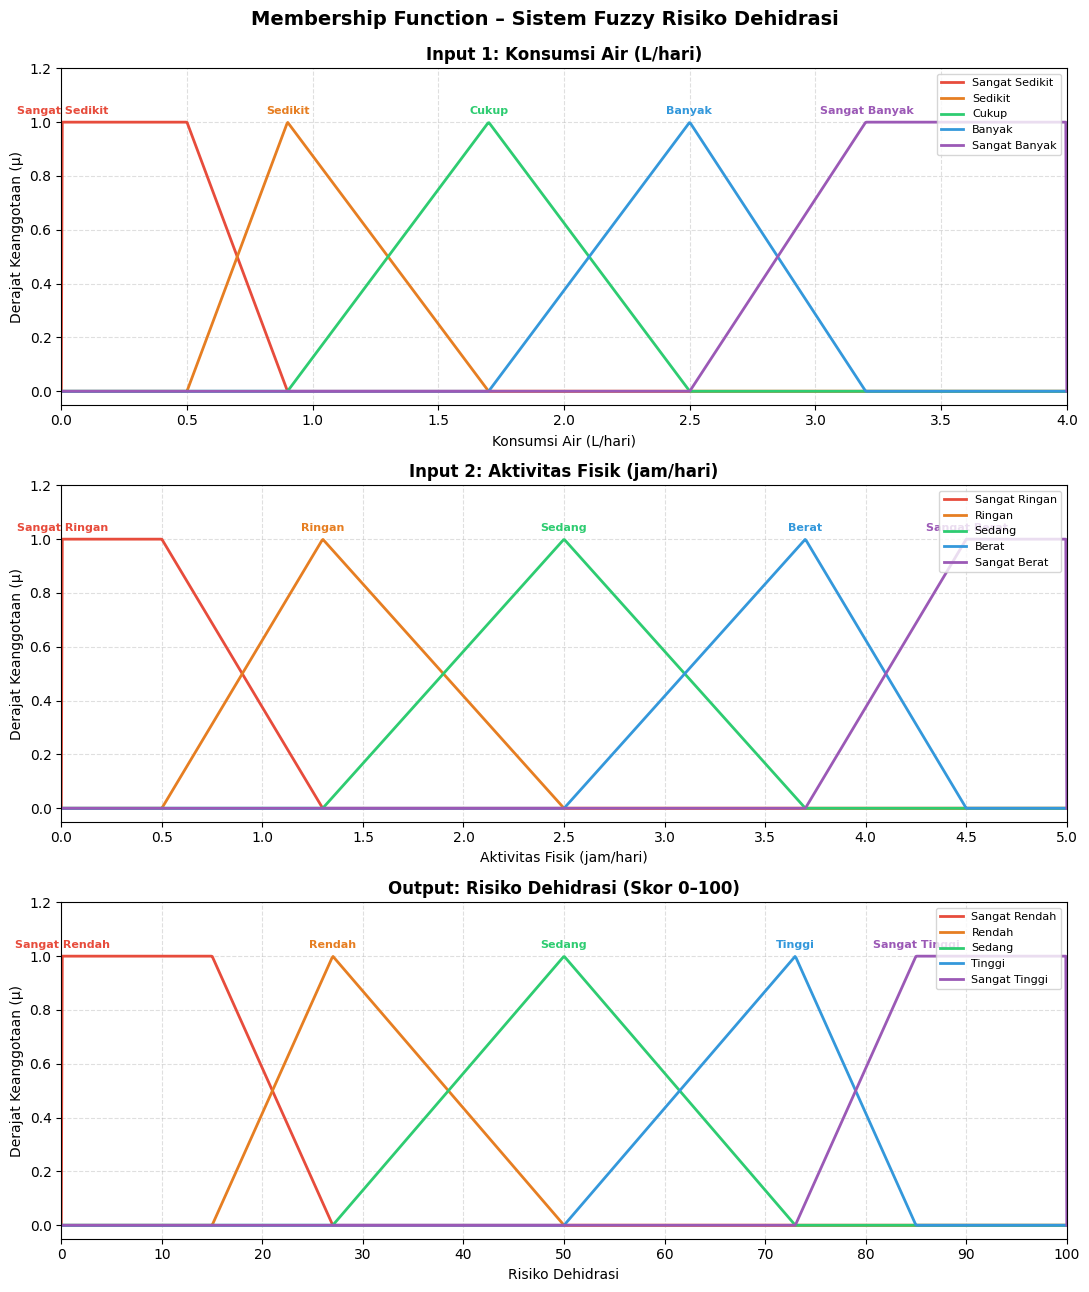


       TABEL PERBANDINGAN HASIL FUZZY – RISIKO DEHIDRASI
Test Case  Air (L)  Aktivitas (jam)  Max  Sugeno  Mamdani                            Rule Dominan
      TC1      0.5              0.5   27   27.00    30.67 Sangat Sedikit & Sangat Ringan → Rendah
      TC2      1.0              2.5   50   47.12    48.17               Sedikit & Sedang → Sedang
      TC3      2.0              4.0   50   50.00    50.00                  Cukup & Berat → Sedang
      TC4      3.5              1.5   15   15.00    11.21  Sangat Banyak & Ringan → Sangat Rendah


In [18]:
# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    plot_membership_functions()
    run_tabel()